RNN - Erro dos pesos computados e usado somente durante a iteração

In [1]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import time
from Functions.Utils import *
from Functions.RLS import *
from Functions.RTLO import *
from Functions.Graphs import *
from Functions.TEDA import *
from Functions.TedaGraphs import *
import optuna
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.samplers import RandomSampler
import os
import re
import sys
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import random
import pickle
FileName = ipynbname.name()
K=0

def superscript(texto):
    normal = "0123456789+-=()"
    super_s = "⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻⁼⁽⁾"
    tabela = str.maketrans(normal, super_s)
    return texto.translate(tabela)

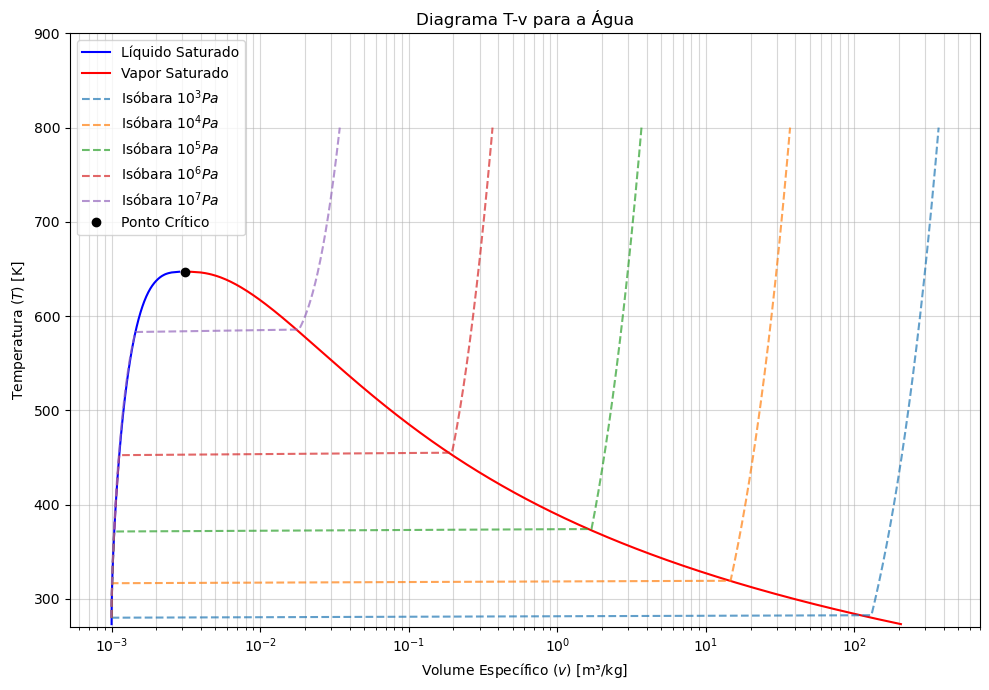

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# Configurações iniciais
substance = 'Water'
T_crit = PropsSI('Tcrit', substance)
P_crit = PropsSI('Pcrit', substance)

# 1. Gerar a Curva de Saturação (Domo)
T_range = np.linspace(273.16 + 0.01, T_crit - 0.05, 500)
v_fluid = [1/PropsSI('D', 'T', t, 'Q', 0, substance) for t in T_range]
v_gas = [1/PropsSI('D', 'T', t, 'Q', 1, substance) for t in T_range]

plt.figure(figsize=(10, 7))

# Plotar as linhas de saturação
plt.plot(v_fluid, T_range, 'b-', label='Líquido Saturado')
plt.plot(v_gas, T_range, 'r-', label='Vapor Saturado')

# 2. Adicionar Isóbaras (Linhas de Pressão Constante)
pressures = [10**i for i in range(3,8)] # 1 bar, 10 bar, P_crit (Pa)
labels = [f'$10^{i}Pa$' for i in range(3,8)]

for p, label in zip(pressures, labels):
    # Temperaturas para a isóbara
    T_iso = np.linspace(280, 800, 200)
    v_iso = []
    for t in T_iso:
        try:
            # Calcula o volume específico (1/densidade)
            v = 1/PropsSI('D', 'T', t, 'P', p, substance)
            v_iso.append(v)
        except:
            continue
    plt.plot(v_iso, T_iso, '--', label=f'Isóbara {label}', alpha=0.7)

# Ponto Crítico
v_crit = 1/PropsSI('D', 'T', T_crit, 'P', P_crit, substance)
out = 'Water_t-v_diagram.png'
plt.plot(v_crit, T_crit, 'ko', label='Ponto Crítico')

# Formatação do Gráfico
plt.xscale('log') # Escala logarítmica é essencial para visualizar o volume
plt.xlabel('Volume Específico ($v$) [m³/kg]')
plt.ylabel('Temperatura ($T$) [K]')
plt.title('Diagrama T-v para a Água')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.ylim(270, 900)
plt.tight_layout() 
plt.savefig(out, dpi=500, transparent=False)
plt.show()

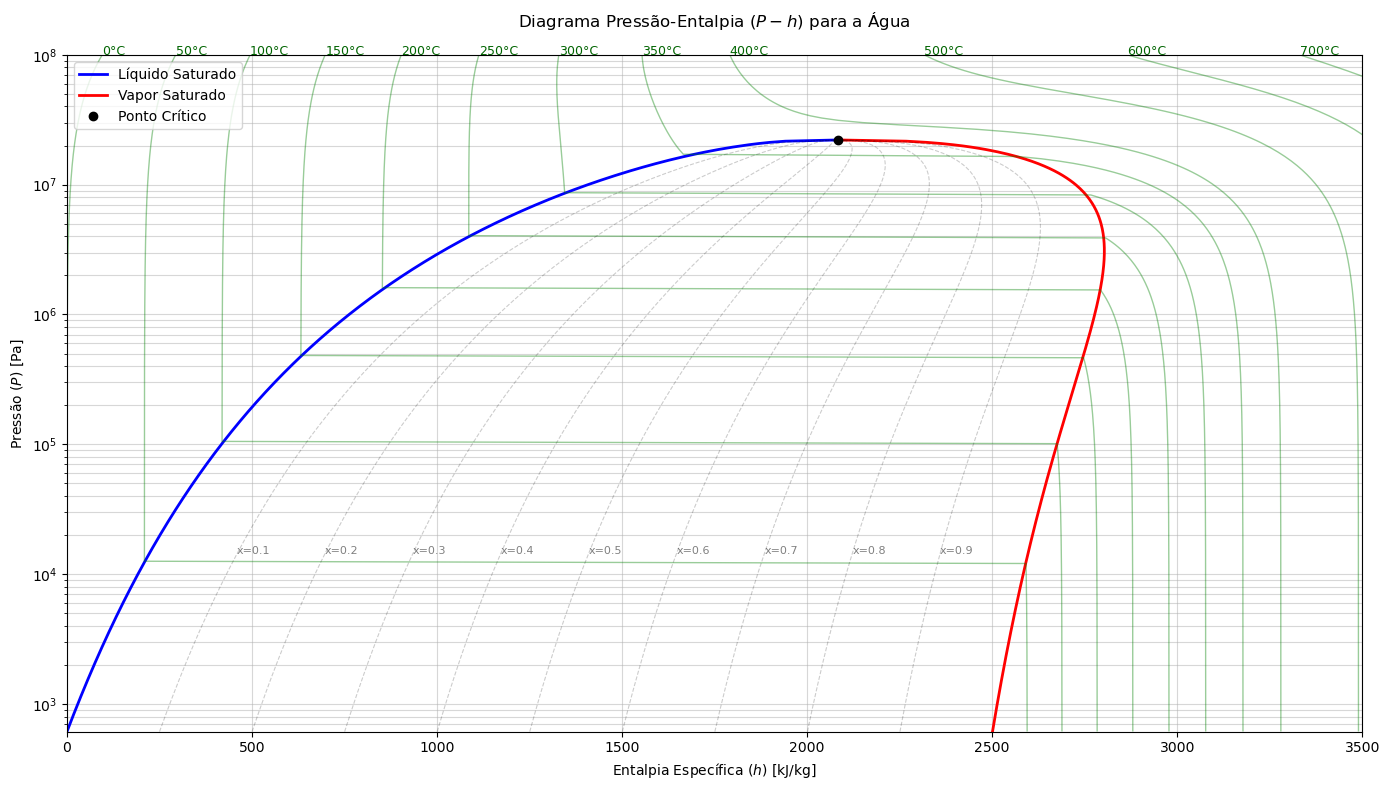

In [13]:
import numpy as np

import matplotlib.pyplot as plt

from CoolProp.CoolProp import PropsSI



# Configurações iniciais

substance = 'Water'

T_crit = PropsSI('Tcrit', substance)

P_crit = PropsSI('Pcrit', substance)

P_triple = PropsSI('ptriple', substance)



# 1. Gerar a Curva de Saturação (Domo)

# Geramos um range de pressões do ponto triplo até o ponto crítico

P_range = np.geomspace(P_triple + 1, P_crit - 100, 500)

h_fluid = [PropsSI('H', 'P', p, 'Q', 0, substance) / 1000 for p in P_range] # kJ/kg

h_gas = [PropsSI('H', 'P', p, 'Q', 1, substance) / 1000 for p in P_range]   # kJ/kg



plt.figure(figsize=(14, 8))



# Plotar as linhas de saturação (Domo)

plt.plot(h_fluid, P_range, 'b-', label='Líquido Saturado', linewidth=2)

plt.plot(h_gas, P_range, 'r-', label='Vapor Saturado', linewidth=2)



# 2. Adicionar Isotermas (Linhas de Temperatura Constante)

# Temperaturas de interesse em Celsius

temp_celsius = [0, 50, 100, 150, 200, 250, 300,350, 400, 500, 600, 700]

for tc in temp_celsius:

    T_iso = tc + 273.15

    # Range de pressões para a isoterma (do ponto triplo até 100 MPa)

    p_plot = np.geomspace(P_triple + 10, 100e6, 300)

    h_iso = []

    for p in p_plot:

        try:

            h = PropsSI('H', 'T', T_iso, 'P', p, substance) / 1000

            h_iso.append(h)

        except:

            h_iso.append(np.nan)

   

    plt.plot(h_iso, p_plot, 'g-', alpha=0.4, linewidth=1)

   

    # Adicionar o rótulo da temperatura no final da linha (região de superaquecimento)

    if not np.isnan(h_iso[-1]):

        plt.text(h_iso[-1], p_plot[-1], f'{tc}°C', fontsize=9, color='darkgreen')



# 3. Adicionar Linhas de Título Constante (Qualidade x)

# Comuns em diagramas P-h para identificar o estado dentro do domo

qualities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for q in qualities:

    h_q = [PropsSI('H', 'P', p, 'Q', q, substance) / 1000 for p in P_range]

    plt.plot(h_q, P_range, 'k--', alpha=0.2, linewidth=0.8)

    #if q == 0.5: # Adiciona o rótulo apenas para x=0.5 para não poluir

    plt.text(h_q[150], P_range[150], f'x={q}', fontsize=8, alpha=0.5)



# Ponto Crítico

h_crit = PropsSI('H', 'T', T_crit, 'Q', 0, substance) / 1000

plt.plot(h_crit, P_crit, 'ko', label='Ponto Crítico')



# Formatação do Gráfico

plt.yscale('log') # Eixo da pressão em escala logarítmica

plt.xlabel('Entalpia Específica ($h$) [kJ/kg]')

plt.ylabel('Pressão ($P$) [Pa]')

plt.title('Diagrama Pressão-Entalpia ($P-h$) para a Água', pad=20)

plt.grid(True, which="both", ls="-", alpha=0.5)

plt.legend(loc='upper left')



# Ajuste de limites para focar no domo e região de interesse

plt.xlim(0, 3500)

plt.ylim(P_triple, 100e6)



plt.tight_layout()

plt.savefig(r'C:\Users\claud\OneDrive\Imagens\Termodinâmica\Water_p-h_diagram.png', dpi=500)

plt.show()

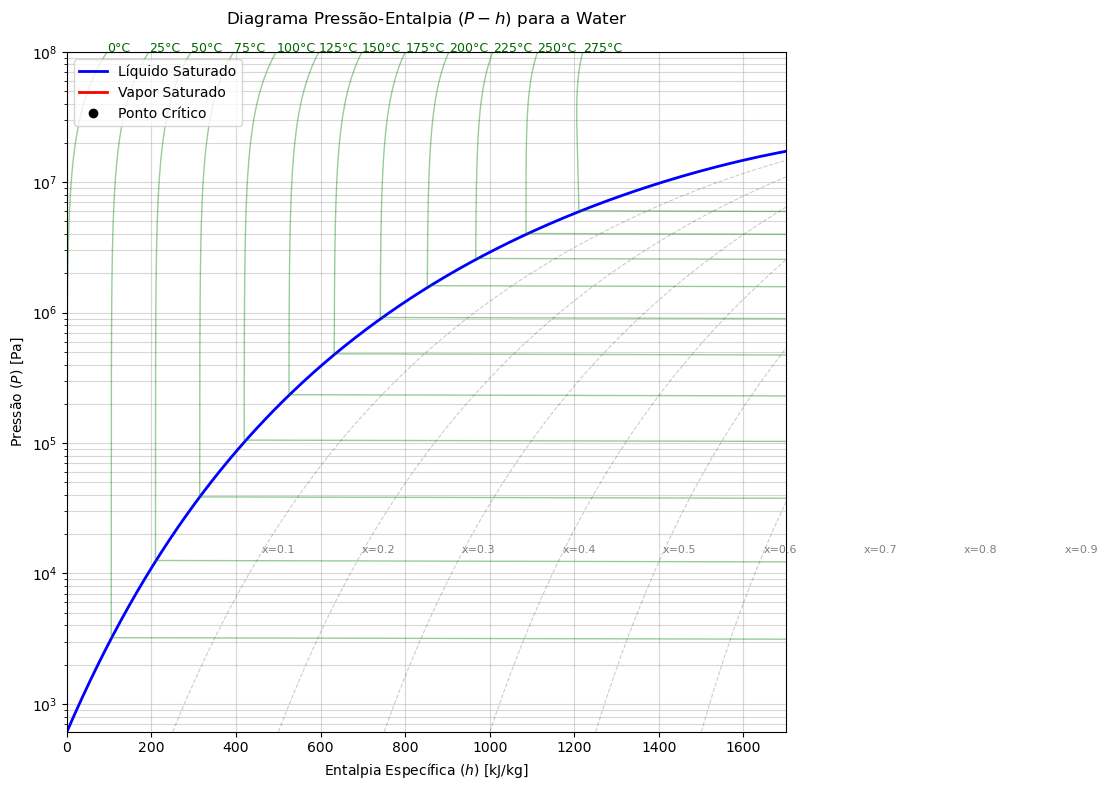

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# Configurações iniciais
substance = 'Water'
T_crit = PropsSI('Tcrit', substance)
P_crit = PropsSI('Pcrit', substance)
P_triple = PropsSI('ptriple', substance)

# 1. Gerar a Curva de Saturação (Domo)
# Geramos um range de pressões do ponto triplo até o ponto crítico
P_range = np.geomspace(P_triple + 1, P_crit - 100, 500)
h_fluid = [PropsSI('H', 'P', p, 'Q', 0, substance) / 1000 for p in P_range] # kJ/kg
h_gas = [PropsSI('H', 'P', p, 'Q', 1, substance) / 1000 for p in P_range]   # kJ/kg

plt.figure(figsize=(12, 8))

# Plotar as linhas de saturação (Domo)
plt.plot(h_fluid, P_range, 'b-', label='Líquido Saturado', linewidth=2)
plt.plot(h_gas, P_range, 'r-', label='Vapor Saturado', linewidth=2)

# 2. Adicionar Isotermas (Linhas de Temperatura Constante)
# Temperaturas de interesse em Celsius
temp_celsius = [0, 50, 100, 150, 200, 250]
temp_celsius = [i*25 for i in range(12)]
for tc in temp_celsius:
    T_iso = tc + 273.15
    # Range de pressões para a isoterma (do ponto triplo até 100 MPa)
    p_plot = np.geomspace(P_triple + 10, 100e6, 300)
    h_iso = []
    for p in p_plot:
        try:
            h = PropsSI('H', 'T', T_iso, 'P', p, substance) / 1000
            h_iso.append(h)
        except:
            h_iso.append(np.nan)
    
    plt.plot(h_iso, p_plot, 'g-', alpha=0.4, linewidth=1)
    
    # Adicionar o rótulo da temperatura no final da linha (região de superaquecimento)
    if not np.isnan(h_iso[-1]):
        plt.text(h_iso[-1], p_plot[-1], f'{tc}°C', fontsize=9, color='darkgreen')

# 3. Adicionar Linhas de Título Constante (Qualidade x)
# Comuns em diagramas P-h para identificar o estado dentro do domo
qualities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for q in qualities:
    h_q = [PropsSI('H', 'P', p, 'Q', q, substance) / 1000 for p in P_range]
    plt.plot(h_q, P_range, 'k--', alpha=0.2, linewidth=0.8)
    #if q == 0.5: # Adiciona o rótulo apenas para x=0.5 para não poluir
    plt.text(h_q[150], P_range[150], f'x={q}', fontsize=8, alpha=0.5)

# Ponto Crítico
h_crit = PropsSI('H', 'T', T_crit, 'Q', 0, substance) / 1000
plt.plot(h_crit, P_crit, 'ko', label='Ponto Crítico')

# Formatação do Gráfico
plt.yscale('log') # Eixo da pressão em escala logarítmica
plt.xlabel('Entalpia Específica ($h$) [kJ/kg]')
plt.ylabel('Pressão ($P$) [Pa]')
plt.title('Diagrama Pressão-Entalpia ($P-h$) para a Water', pad=20)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper left')

# Ajuste de limites para focar no domo e região de interesse
plt.xlim(0,1700)
plt.ylim(P_triple, 100e6)

plt.tight_layout()
plt.savefig(r'C:\Users\claud\OneDrive\Imagens\Termodinâmica\Water_p-h_diagram.png', dpi=500)
plt.show()

In [5]:
t

array([ 0.        ,  0.25641026,  0.51282051,  0.76923077,  1.02564103,
        1.28205128,  1.53846154,  1.79487179,  2.05128205,  2.30769231,
        2.56410256,  2.82051282,  3.07692308,  3.33333333,  3.58974359,
        3.84615385,  4.1025641 ,  4.35897436,  4.61538462,  4.87179487,
        5.12820513,  5.38461538,  5.64102564,  5.8974359 ,  6.15384615,
        6.41025641,  6.66666667,  6.92307692,  7.17948718,  7.43589744,
        7.69230769,  7.94871795,  8.20512821,  8.46153846,  8.71794872,
        8.97435897,  9.23076923,  9.48717949,  9.74358974, 10.        ])

In [10]:
A = 1
ω_n = 0.5
φ = 0

def pos(t):
    return A*np.cos(ω_n*t - φ)

t = np.linspace(0,20,400)
y = pos(t)

plot_single(y=y,x=t,w=1200,h=600)

In [34]:
def circ(x,x0,y0):
    return np.sqrt(1-((x-x0)**2))+y0

x0=3
y0=3
x = np.linspace(x0-1,x0+1,100)
y1 = circ(x,x0,y0)
y2 = -y1+(y1[0]-(-y1[0]))
#plot_single(x=x,y=y)
plot_2series(x1=x,x2=x,y1=y1,y2=y2)

In [1]:
new=10